Repo URL: https://github.com/<redacted>/assignment-4-equation-of-a-slime-<redacted>
Commit ID: defb3cd

In [1]:
# Imports section
import pandas as pd
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from IPython.display import display, Markdown

## Part 1. Loading the dataset

First 15 rows of dataset:
    Temperature °C  Mols KCL     Size nm^3
0              469       647  6.244743e+05
1              403       694  5.779610e+05
2              302       975  6.196847e+05
3              779       916  1.460449e+06
4              901        18  4.325726e+04
5              545       637  7.124634e+05
6              660       519  7.006960e+05
7              143       869  2.718260e+05
8               89       461  8.919803e+04
9              294       776  4.770210e+05
10             991       117  2.441771e+05
11             307       781  5.006455e+05
12             206        70  3.145200e+04
13             437       599  5.390215e+05
14             566        75  9.185271e+04
Number of datapoints: 1000
Shape: (1000, 3)


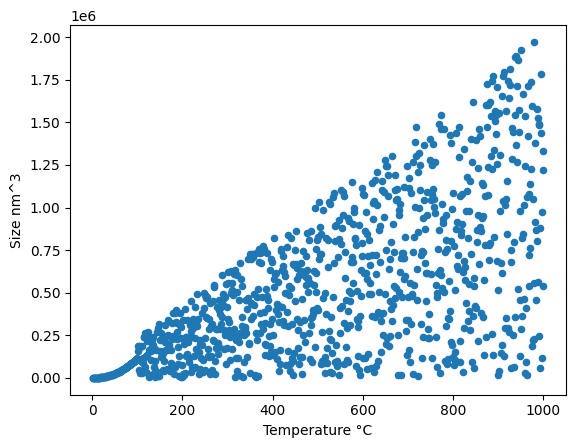

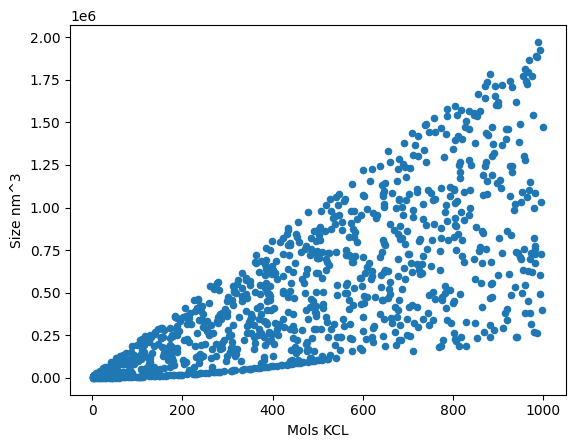

In [2]:
# Using pandas load the dataset (load remotely, not locally)
# Output the first 15 rows of the data
# Display a summary of the table information (number of datapoints, etc.)
df = pd.read_csv('/workspaces/assignment-4-equation-of-a-slime-<redacted>/science_data_large.csv')
first_15_rows = df.head(15)
print("First 15 rows of dataset:")
print(first_15_rows)
print("Number of datapoints: " + str(len(df)))
print("Shape: " + str(df.shape))
plot = df.plot.scatter(x=0,y=2)
plot2 = df.plot.scatter(x=1,y=2)

## Part 2. Splitting the dataset

In [3]:
# Take the pandas dataset and split it into our features (X) and label (y)
# Features: the data we use for classification (temperature and mols KCL)
X = df.iloc[:, :-1]
# Labels: the data we want to be able to predict (size)
y = df.iloc[:, [-1]]
# Use sklearn to split the features and labels into a training/test set. (90% train, 10% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)
print("training features:")
print(X_train)
print("testing features:")
print(X_test)
print("training labels: ")
print(y_train)
print("testing labels:")
print(y_test)

training features:
     Temperature °C  Mols KCL
687             289       814
500             229       130
332             653       172
979             693       422
817             380       957
..              ...       ...
835               6        13
192             430       560
629             153       801
559             726       744
684             493       979

[800 rows x 2 columns]
testing features:
     Temperature °C  Mols KCL
993             311       265
859             951       145
298             985       786
553              66       317
672              59       277
..              ...       ...
679             770        12
722             810       436
215             891       736
653             692       498
150             541       804

[200 rows x 2 columns]
training labels: 
        Size nm^3
687  4.928913e+05
500  6.277086e+04
332  2.333133e+05
979  5.982961e+05
817  7.580471e+05
..            ...
835  2.328286e+02
192  4.957200e+05
629  2.652735e+

## Part 3. Perform a Linear Regression

In [4]:
# Use sklearn to train a model on the training set
model = LinearRegression()
model = model.fit(X_train, y_train)


# Create a sample datapoint and predict the output of that sample with the trained model
sample = X_test.sample(n=1)
print("sample: \n" + str(sample))
print("predicted output: " + str('{:.2e}'.format(model.predict(sample)[0][0])) + "\n")

# Report on the score for that model, in your own words (markdown, not code) explain what the score means

# Extract the coefficents and intercept from the model and write an equation for your h(x) using LaTeX
coeflist = model.coef_.tolist()[0]

display(Markdown(rf"""
Linear regression coefficients: ${coeflist[0]},{coeflist[1]}$

Intercept: ${model.intercept_[0]}$

$h(x)={coeflist[0]}x_0+{coeflist[1]}x_1+{model.intercept_[0]}$, where $x_0$ is temperature in $\degree$ C and $x_1$ is moles KCL.
"""))

sample: 
     Temperature °C  Mols KCL
653             692       498
predicted output: 7.02e+05




Linear regression coefficients: $863.8038601435101,1018.2025416628443$

Intercept: $-402757.2875786738$

$h(x)=863.8038601435101x_0+1018.2025416628443x_1+-402757.2875786738$, where $x_0$ is temperature in $\degree$ C and $x_1$ is moles KCL.


Sample equation: $E = mc^2$

## Part 4. Use Cross Validation

In [5]:
# Use the cross_val_score function to repeat your experiment across many shuffles of the data
cross_vals_linear = cross_val_score(model, X, y, cv=5)
display(cross_vals_linear)
# Report on their finding and their significance
display(Markdown(rf"""
The 5 values above represent the $R^2$ values of the linear regression model at 5 different shuffles. $R^2$ is the coefficient of determination and $R^2= (1-\frac{"{u}"}{"{v}"})$ where $u$
is the residual sum of squares and $v$ is the total sum of squares. The regression scores average to ${sum(cross_vals_linear)/len(cross_vals_linear)}$, and the best possible score is $1.0$.
The linear regression model is somewhat accurate based on this coefficient.
"""))

array([0.83918826, 0.87051239, 0.85871066, 0.87202623, 0.84364641])


The 5 values above represent the $R^2$ values of the linear regression model at 5 different shuffles. $R^2$ is the coefficient of determination and $R^2= (1-\frac{u}{v})$ where $u$
is the residual sum of squares and $v$ is the total sum of squares. The regression scores average to $0.8568167899144437$, and the best possible score is $1.0$.
The linear regression model is somewhat accurate based on this coefficient.


## Part 5. Using Polynomial Regression

In [14]:
# Using the PolynomialFeatures library perform another regression on an augmented dataset of degree 2
poly_model = PolynomialFeatures(degree=2)
poly_model = poly_model.fit(X_train, y_train)
# Report on the metrics and output the resultant equation as you did in Part 3.
display(poly_model.get_params())
X_poly = poly_model.fit_transform(X)
lin2 = LinearRegression()
lin2 = lin2.fit(X_poly, y)
lin2.coef_
coef_list_poly = lin2.coef_.tolist()[0]

display(Markdown(rf"""
Polynomial regression coefficients: ${coef_list_poly[0]}, {coef_list_poly[1]}, {coef_list_poly[2]}, {coef_list_poly[3]}, {coef_list_poly[4]}, {coef_list_poly[5]}$

Intercept: ${lin2.intercept_[0]}$

$h(x)={coef_list_poly[0]}+{coef_list_poly[1]}x_1+{coef_list_poly[2]}x_2+{coef_list_poly[3]}x_1^2+{coef_list_poly[4]}x_2^2+{coef_list_poly[5]}x_1x_2+{lin2.intercept_[0]}$
"""))



{'degree': 2, 'include_bias': True, 'interaction_only': False, 'order': 'C'}


Polynomial regression coefficients: $0.0, 12.00000000286887, -1.231105042475561e-07, -1.056488230233299e-11, 2.000000000013513, 0.028571428703912716$

Intercept: $1.657189568504691e-05$

$h(x)=0.0+12.00000000286887x_1+-1.231105042475561e-07x_2+-1.056488230233299e-11x_1^2+2.000000000013513x_2^2+0.028571428703912716x_1x_2+1.657189568504691e-05$
